# How Hungary's VSC Compressed Antonelli's Tyre Gamble

*A lap-by-lap and near-continuous reconstruction shows how Hamilton returned
to the podium fight and why the lap-58 position change was not an
overtake.*

## Editorial note

This notebook grew out of Candidate E2 in a separate, earlier notebook `02_hungarian_gp_2026_external_candidate_followup.ipynb`, which screened
three externally sourced story candidates after this project's original
story-discovery audit had already closed. That notebook classified the
Antonelli-Hamilton sequence as `SECONDARY / SHORT-FORM` solid enough to
verify and quantify, but not a standalone discovery, since its governing
mechanism is already publicly documented.

This notebook does not reuse that label again. It is a self-contained
article notebook: it loads its own FastF1 session, reads and validates its
own supporting evidence, and reproduces every headline number from
scratch. It does not import, execute, or depend on either of the two
notebooks that came before it.

## The central finding

Kimi Antonelli built a genuine tyre-age advantage over Lewis Hamilton in the
closing stint of the 2026 Hungarian Grand Prix, and for a few laps in the
middle of the race's only Virtual Safety Car period, that advantage nearly
evaporated. A reconstructed lap-boundary time difference swings from
Antonelli leading by six seconds to Hamilton leading by more than fifteen,
then collapses to under a second and a half within a single lap once
Hamilton's own VSC-timed stop is complete. What happened next, Hamilton
handing the position back to Antonelli, was not a pass on track. It was a
timing correction at the relevant control line, applied because Antonelli
had reached that line first. Antonelli still had to defend the position to
the flag; the correction only restored the order that the control line said
was already there.

## Why Antonelli had created a tyre offset

Mercedes went long. Rather than following the two- or three-stop rhythm of
the cars immediately around them, the team held Kimi Antonelli out on his
second set of tyres well past the point most of the field had already
pitted, banking tyre life for the closing laps in exchange for track
position it would need to defend later. Mercedes' own race report frames
the intent plainly: the plan was to build "a significant tyre life
advantage over the cars ahead," giving Antonelli the pace to move into
podium contention as the race matured (Mercedes-AMG PETRONAS F1 Team, race
report, accessed 2026-07-31).

That is the trade a tyre-offset strategy always makes: less time spent
fighting for position early, in exchange for a car that should, in theory,
be quicker than its immediate rivals once they are all on comparably worn
rubber. It is a bet that only pays off if nothing external resets the
clock. A Virtual Safety Car is exactly the kind of external event that can.

Two different things were true of Hamilton at the moment the VSC appeared.
He was ahead of Antonelli on the road because Antonelli had already made his
own final stop, while Hamilton still had one to come, and he was doing it on
older tyres of his own. Those are separate facts: Antonelli's tyre-life
advantage was a strategic asset Mercedes had banked over many laps; the
track gap between the two cars at that moment was simply a consequence of
which of them had already stopped. When Oscar Piastri's McLaren stopped on
track with a gearbox problem and brought out the VSC, every car left with a
pit stop still to make suddenly had a much cheaper one available, including
Hamilton's outstanding stop.

## Data sources and what the timing measures actually mean

This piece leans on sources in a deliberate order. Where the FIA has issued
a decision document, that document is authoritative for penalties and
classification. Where Formula 1 or a team has published an official
account, that account is treated as the best available description of what
happened on track and why. FastF1 supplies the reproducible lap, sector,
pit, stint, and race-control data that every calculated number in this
notebook is built from. Preserved and newly retrieved OpenF1 records supply
additional timestamped context. Independent journalism is used only to
check whether this specific quantitative reconstruction has already been
published elsewhere, never as a substitute for the sources above it.

Primary references used throughout, with the date each was checked:

- FIA, Document 57: car 44 pit lane speeding infringement:
  <https://www.fia.com/system/files/decision-document/2026_hungarian_grand_prix_-_infringement_-_car_44_-_pit_lane_speeding.pdf>
  (accessed 2026-07-31)
- FIA, Document 62: final race classification:
  <https://www.fia.com/system/files/decision-document/2026_hungarian_grand_prix_-_final_race_classification.pdf>
  (accessed 2026-07-31)
- FIA race summary:
  <https://www.fia.com/news/f1-norris-wins-hungary-piastri-retires-and-verstappen-claims-second-ahead-antonelli>
  (accessed 2026-07-31)
- Formula 1, official race report:
  <https://www.formula1.com/en/latest/article/norris-beats-verstappen-and-antonelli-to-victory-in-dramatic-hungarian-gp.5JQmohRAKABD2asRsMWogj>
  (accessed 2026-07-31)
- Mercedes-AMG PETRONAS F1 Team, race report:
  <https://www.mercedesamgf1.com/reports/race-report-impressive-fightbacks-and-damage-limitation-in-budapest>
  (accessed 2026-07-31)
- FastF1 documentation, time representation:
  <https://docs.fastf1.dev/time_explanation.html> (accessed 2026-07-31)
- OpenF1 API documentation:
  <https://openf1.org/docs/> (accessed 2026-07-31)

Two different kinds of "gap" appear below, and they are not interchangeable.

**FastF1 lap-boundary time difference.** For two drivers A and B at
completed lap N, using FastF1's own cumulative session `Time` field:

```
LapBoundaryDifference_A_minus_B(N) = A.Time(N) - B.Time(N)
```

Negative means A completed that lap boundary earlier (A ahead); positive
means B completed it earlier (B ahead). This compares total elapsed time to
finish the *same lap number*, once per lap. It is not an official,
continuously sampled interval.

**OpenF1 synchronized-sample reconstruction.** OpenF1 publishes each
driver's `gap_to_leader` on its own irregular sampling schedule, several
times per lap. Pairing Antonelli's and Hamilton's nearest observations in
time gives a near-continuous view, useful for narrowing down *when*
within a lap something changed, at the cost of a small, disclosed timestamp
skew between the two paired samples. This notebook calls it exactly that:
a synchronized-sample reconstruction, never an official direct
driver-to-driver interval.


## Environment, cache, and independent session load

The next few cells set up a portable environment, load this race's FastF1
session independently of any other notebook, and validate the inputs before
any calculation runs. This mirrors the portable-infrastructure pattern
already used in Notebooks 1 and 2 in this project.

In [1]:
import sys
import platform
from pathlib import Path

import fastf1
import pandas as pd
import numpy as np
import matplotlib
import IPython
import ipykernel

print("Python        :", sys.version.replace("\n", " "))
print("Platform      :", platform.platform())
print("FastF1        :", fastf1.__version__)
print("pandas        :", pd.__version__)
print("NumPy         :", np.__version__)
print("Matplotlib    :", matplotlib.__version__)
print("IPython       :", IPython.__version__)
print("ipykernel     :", ipykernel.__version__)
print("Executable    :", Path(sys.executable).name)

Python        : 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
Platform      : macOS-26.3-arm64-arm-64bit
FastF1        : 3.8.3
pandas        : 2.3.3
NumPy         : 2.4.4
Matplotlib    : 3.10.9
IPython       : 9.13.0
ipykernel     : 7.2.0
Executable    : python


In [2]:
import os

default_cache_root = Path(
    os.environ.get("XDG_CACHE_HOME", Path.home() / ".cache")
)

FASTF1_CACHE_DIR = Path(
    os.environ.get(
        "FASTF1_CACHE",
        default_cache_root / "fastf1" / "Hungarian_GP_2026",
    )
).expanduser()

FASTF1_CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(FASTF1_CACHE_DIR))

cache_source = (
    "FASTF1 environment variable"
    if os.environ.get("FASTF1_CACHE")
    else "per-user cache default"
)
print("FastF1 cache configured:", cache_source)

FastF1 cache configured: per-user cache default


### Independent session load

This notebook loads its own session object. It does not read or depend on
any in-memory object from Notebook 1 or Notebook 2. Telemetry and weather
are excluded, since none of the calculations below need them.

In [3]:
session = fastf1.get_session(2026, "Hungary", "R")
session.load(
    laps=True,
    telemetry=False,
    weather=False,
    messages=True,
)

laps = session.laps.copy()
laps["LapTimeSec"] = laps["LapTime"].dt.total_seconds()

print("Session loaded independently:", session)
print("laps.shape:", laps.shape)

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

core           INFO 	Processing timing data...


core        WARNING 	Fixed incorrect tyre stint information for driver '11'


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['1', '3', '12', '16', '44', '6', '63', '30', '27', '41', '5', '10', '18', '14', '43', '31', '23', '55', '87', '81', '11', '77']


Session loaded independently: 2026 Season Round 11: Hungarian Grand Prix - Race
laps.shape: (1431, 32)


### Input and source validation

Before any headline number is calculated, this cell verifies the driver
mappings and the OpenF1 session key against the loaded session and the
preserved evidence file, rather than assuming either.

In [4]:
required_columns = [
    "Driver", "LapNumber", "LapTime", "Time", "Stint", "Compound",
    "TyreLife", "PitInTime", "PitOutTime", "TrackStatus", "Position",
]
missing_columns = sorted(set(required_columns) - set(laps.columns))
assert not missing_columns, f"Missing required columns: {missing_columns}"

results = session.results
ant_result = results.loc[results["Abbreviation"].eq("ANT")].iloc[0]
ham_result = results.loc[results["Abbreviation"].eq("HAM")].iloc[0]

assert int(ant_result["DriverNumber"]) == 12, "Antonelli is not driver number 12"
assert int(ham_result["DriverNumber"]) == 44, "Hamilton is not driver number 44"

print("Verified from the loaded session (not assumed):")
print(f"  ANT -> driver number {int(ant_result['DriverNumber'])}, {ant_result['FullName']}")
print(f"  HAM -> driver number {int(ham_result['DriverNumber'])}, {ham_result['FullName']}")

# Repository-relative evidence resolution: works from the repo root or from
# within notebooks/.
evidence_candidates = [
    Path("evidence/openf1_hungary_2026_race_control.json"),
    Path("../evidence/openf1_hungary_2026_race_control.json"),
]
race_control_evidence_path = next(
    (p for p in evidence_candidates if p.is_file()), None
)
assert race_control_evidence_path is not None, (
    "Preserved OpenF1 race-control evidence file not found from the "
    "current working directory"
)

import json
with open(race_control_evidence_path) as f:
    preserved_race_control = json.load(f)

preserved_session_keys = set(r.get("session_key") for r in preserved_race_control)
assert preserved_session_keys == {11342}, (
    f"Unexpected session_key(s) in preserved evidence: {preserved_session_keys}"
)
print()
print(
    "Verified: preserved OpenF1 race-control evidence uses session_key "
    "11342, matching this session."
)

Verified from the loaded session (not assumed):
  ANT -> driver number 12, Kimi Antonelli
  HAM -> driver number 44, Lewis Hamilton

Verified: preserved OpenF1 race-control evidence uses session_key 11342, matching this session.


## The lap-boundary chronology

Antonelli's own stop was a green-flag affair on lap 53, well before the
VSC. Hamilton's stop came three laps later, on lap 56, squarely inside the
VSC window. FastF1 and OpenF1 both attach Antonelli's pit entry to his
in-lap, 53, and his pit exit to the following lap, 54; Formula 1's own
narrative race report describes the same physical stop as happening on
"Lap 54." Both descriptions refer to the same single stop -- this is a
difference in which lap number is used to label a pit-in-to-pit-out event,
not a disagreement between sources about what happened. This notebook
consistently uses the `PitInTime`/`PitOutTime` convention (in-lap 53,
out-lap 54) for Antonelli throughout. The cell below pulls both drivers'
laps 48-60, confirms the pit laps directly from FastF1's own
`PitInTime`/`PitOutTime` fields, and computes the lap-boundary time
difference at each lap boundary in the window.

In [5]:
e2_window = list(range(48, 61))

ant_laps = (
    laps.loc[laps["Driver"].eq("ANT") & laps["LapNumber"].isin(e2_window)]
    .sort_values("LapNumber")
    .copy()
)
ham_laps = (
    laps.loc[laps["Driver"].eq("HAM") & laps["LapNumber"].isin(e2_window)]
    .sort_values("LapNumber")
    .copy()
)

assert not ant_laps["LapNumber"].duplicated().any()
assert not ham_laps["LapNumber"].duplicated().any()
assert ant_laps["Time"].notna().all() and ham_laps["Time"].notna().all()

ant_idx = ant_laps.set_index("LapNumber")
ham_idx = ham_laps.set_index("LapNumber")

assert pd.notna(ant_idx.loc[53, "PitInTime"]), "Antonelli PitInTime on lap 53 not found"
assert pd.notna(ant_idx.loc[54, "PitOutTime"]), "Antonelli PitOutTime on lap 54 not found"
assert pd.notna(ham_idx.loc[56, "PitInTime"]), "Hamilton PitInTime on lap 56 not found"
assert pd.notna(ham_idx.loc[57, "PitOutTime"]), "Hamilton PitOutTime on lap 57 not found"

print("Verified: Antonelli PitInTime lap 53 / PitOutTime lap 54 (green-flag stop).")
print("Verified: Hamilton PitInTime lap 56 / PitOutTime lap 57 (VSC-window stop).")

paired = (
    ant_laps[["LapNumber", "Time"]]
    .merge(
        ham_laps[["LapNumber", "Time"]],
        on="LapNumber", how="inner", suffixes=("_ANT", "_HAM"),
        validate="one_to_one",
    )
    .sort_values("LapNumber")
    .reset_index(drop=True)
)
assert paired["LapNumber"].is_unique
assert paired["Time_ANT"].notna().all() and paired["Time_HAM"].notna().all()

paired["LapBoundaryDifference_ANT_minus_HAM"] = (
    (paired["Time_ANT"] - paired["Time_HAM"]).dt.total_seconds()
)
diff_at = paired.set_index("LapNumber")["LapBoundaryDifference_ANT_minus_HAM"]

print()
print(
    "FastF1 lap-boundary time difference, ANT-HAM "
    "(negative = ANT ahead, positive = HAM ahead):"
)
print(
    paired[["LapNumber", "LapBoundaryDifference_ANT_minus_HAM"]].to_string(
        index=False,
        formatters={"LapBoundaryDifference_ANT_minus_HAM": "{:+.3f}".format},
    )
)

lap52_value = diff_at.loc[52]
lap54_value = diff_at.loc[54]
lap56_value = diff_at.loc[56]
lap57_value = diff_at.loc[57]
lap58_value = diff_at.loc[58]

print()
print(f"Lap 52: {lap52_value:+.3f} s")
print(f"Lap 54: {lap54_value:+.3f} s")
print(f"Lap 56 (Hamilton's pit-in boundary): {lap56_value:+.3f} s")
print(f"Lap 57 (Hamilton's pit-out boundary): {lap57_value:+.3f} s")
print(f"Lap 58 (after the documented position return): {lap58_value:+.3f} s")

assert abs(lap52_value - (-6.002)) < 0.01
assert abs(lap54_value - 14.190) < 0.01
assert abs(lap56_value - 15.689) < 0.01
assert abs(lap57_value - 1.388) < 0.01
assert abs(lap58_value - (-0.658)) < 0.01

print()
print("All five headline lap-boundary values reproduced within tolerance.")

five_stage_states = {
    "Before Antonelli's stop (laps 51-52)": diff_at.loc[[51, 52]],
    "After Antonelli's stop, before Hamilton's pit-in (laps 54-55)": diff_at.loc[[54, 55]],
    "Hamilton's VSC pit-in boundary (lap 56)": diff_at.loc[[56]],
    "Hamilton's pit-out boundary (lap 57)": diff_at.loc[[57]],
    "After the documented white-line return (laps 58-60)": diff_at.loc[[58, 59, 60]],
}
print()
print("Five event-defined sign states:")
for label, series in five_stage_states.items():
    print(f"  {label}: {series.round(3).tolist()}")

assert (five_stage_states["Before Antonelli's stop (laps 51-52)"] < 0).all()
assert (five_stage_states["After Antonelli's stop, before Hamilton's pit-in (laps 54-55)"] > 0).all()
assert (five_stage_states["Hamilton's VSC pit-in boundary (lap 56)"] > 0).all()
assert (five_stage_states["Hamilton's pit-out boundary (lap 57)"] > 0).all()
assert (five_stage_states["After the documented white-line return (laps 58-60)"] < 0).all()
print()
print("All five event-defined sign states hold.")

Verified: Antonelli PitInTime lap 53 / PitOutTime lap 54 (green-flag stop).
Verified: Hamilton PitInTime lap 56 / PitOutTime lap 57 (VSC-window stop).

FastF1 lap-boundary time difference, ANT-HAM (negative = ANT ahead, positive = HAM ahead):
 LapNumber LapBoundaryDifference_ANT_minus_HAM
      48.0                              -7.647
      49.0                              -7.551
      50.0                              -7.025
      51.0                              -6.412
      52.0                              -6.002
      53.0                              -3.240
      54.0                             +14.190
      55.0                             +12.295
      56.0                             +15.689
      57.0                              +1.388
      58.0                              -0.658
      59.0                              -0.531
      60.0                              -1.684

Lap 52: -6.002 s
Lap 54: +14.190 s
Lap 56 (Hamilton's pit-in boundary): +15.689 s
Lap 57 (Hamilton

### Figure 1

The chart below plots the lap-boundary series computed above.

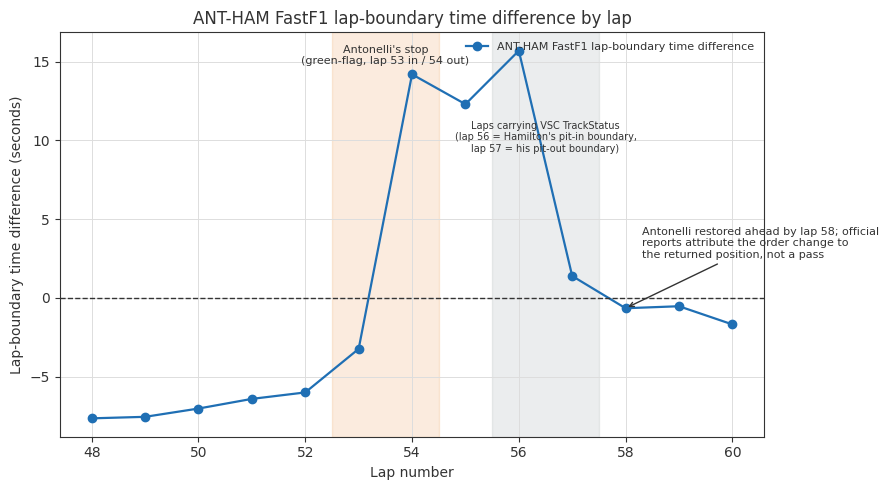

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.7,
})

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    paired["LapNumber"],
    paired["LapBoundaryDifference_ANT_minus_HAM"],
    marker="o",
    color="#1f6fb4",
    linewidth=1.6,
    label="ANT-HAM FastF1 lap-boundary time difference",
)
ax.axhline(0, color="#333333", linewidth=1, linestyle="--")

ax.axvspan(52.5, 54.5, color="#e67e22", alpha=0.15)
ax.annotate(
    "Antonelli's stop\n(green-flag, lap 53 in / 54 out)",
    xy=(53.5, ax.get_ylim()[1] * 0.88),
    ha="center", fontsize=8,
)

ax.axvspan(55.5, 57.5, color="#7f8c8d", alpha=0.15)
ax.annotate(
    "Laps carrying VSC TrackStatus\n(lap 56 = Hamilton's pit-in boundary,\nlap 57 = his pit-out boundary)",
    xy=(56.5, ax.get_ylim()[1] * 0.55),
    ha="center", fontsize=7,
)

ax.annotate(
    "Antonelli restored ahead by lap 58; official\nreports attribute the order change to\nthe returned position, not a pass",
    xy=(58, lap58_value),
    xytext=(58.3, ax.get_ylim()[1] * 0.15),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", lw=1, color="#333333"),
)

ax.set_xlabel("Lap number")
ax.set_ylabel("Lap-boundary time difference (seconds)")
ax.set_title("ANT-HAM FastF1 lap-boundary time difference by lap")
ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

*Figure 1. Antonelli-minus-Hamilton FastF1 lap-boundary time difference,
laps 48-60. Negative values mean Antonelli completed that lap boundary
earlier; positive values mean Hamilton did. This is a lap-boundary
reconstruction from FastF1's cumulative session `Time`, not an official
live interval. The shaded VSC band marks the FastF1 lap records carrying
VSC-related `TrackStatus`; it does not represent the exact within-lap
deployment or ending instant.*

## The VSC timestamp and position reconciliation

FastF1's own race-control table carries an absolute timestamp for each
message, with no manual conversion required. This cell checks that
timestamp directly against the preserved OpenF1 evidence file, and
separately identifies the `TRACK CLEAR` message used later in this
notebook as a resumption proxy, which is not the same instant as the
`VSC ENDING` message.

In [7]:
rcm = session.race_control_messages.copy()
rcm["LapNumeric"] = pd.to_numeric(rcm["Lap"], errors="coerce")

vsc_deployed_msg = rcm.loc[
    rcm["Message"].str.contains("VSC DEPLOYED", case=False, na=False)
].iloc[0]
vsc_ending_msg = rcm.loc[
    rcm["Message"].str.contains("VSC ENDING", case=False, na=False)
].iloc[0]

fastf1_vsc_deployed_utc = vsc_deployed_msg["Time"].tz_localize("UTC")
fastf1_vsc_ending_utc = vsc_ending_msg["Time"].tz_localize("UTC")

print("FastF1 absolute VSC timestamps (already present, no conversion applied):")
print(f"  VSC deployed : {fastf1_vsc_deployed_utc}  (lap {int(vsc_deployed_msg['LapNumeric'])})")
print(f"  VSC ENDING   : {fastf1_vsc_ending_utc}  (lap {int(vsc_ending_msg['LapNumeric'])})")

with open(race_control_evidence_path) as f:
    preserved_race_control = json.load(f)

preserved_vsc_rows = [r for r in preserved_race_control if "VSC" in (r.get("message") or "")]
assert len(preserved_vsc_rows) == 2, "Expected exactly 2 preserved OpenF1 VSC messages"

preserved_deployed_utc = pd.Timestamp(
    [r["date"] for r in preserved_vsc_rows if "DEPLOYED" in r["message"]][0]
).tz_convert("UTC")
preserved_ending_utc = pd.Timestamp(
    [r["date"] for r in preserved_vsc_rows if "ENDING" in r["message"]][0]
).tz_convert("UTC")

expected_deployed = pd.Timestamp("2026-07-26 14:22:55", tz="UTC")
expected_ending = pd.Timestamp("2026-07-26 14:24:13", tz="UTC")

assert fastf1_vsc_deployed_utc == expected_deployed
assert fastf1_vsc_ending_utc == expected_ending
assert preserved_deployed_utc == expected_deployed
assert preserved_ending_utc == expected_ending
assert fastf1_vsc_deployed_utc == preserved_deployed_utc
assert fastf1_vsc_ending_utc == preserved_ending_utc

print()
print(
    "Confirmed: FastF1's own race-control timestamps agree exactly with "
    "the preserved OpenF1 evidence file for both VSC deployed and "
    "VSC ENDING."
)

# TRACK CLEAR is a separate, later message used in this notebook as a
# resumption proxy: do not assume VSC ENDING is the resumption instant.
track_clear_rows = rcm.loc[
    rcm["Message"].str.fullmatch("TRACK CLEAR", case=False, na=False)
]
assert len(track_clear_rows) == 1, (
    f"Expected exactly one TRACK CLEAR message, found {len(track_clear_rows)}"
)
track_clear_msg = track_clear_rows.iloc[0]
track_clear_utc = track_clear_msg["Time"].tz_localize("UTC")

gap_to_track_clear_message = (track_clear_utc - fastf1_vsc_ending_utc).total_seconds()

print()
print(f"TRACK CLEAR message (used as the resumption proxy): {track_clear_utc}  (lap {int(track_clear_msg['LapNumeric'])})")
print(
    f"This is {gap_to_track_clear_message:.0f} seconds after the VSC ENDING "
    "message -- the two are not the same instant, and this notebook does "
    "not treat VSC ENDING as the exact green-flag resumption time. See the "
    "note below on why TRACK CLEAR is used as a resumption proxy rather "
    "than independently verified panel telemetry."
)
assert 10 <= gap_to_track_clear_message <= 15, (
    f"Expected TRACK CLEAR to follow VSC ENDING by 10-15 seconds per FIA "
    f"2026 Sporting Regulations Article B5.12.4, got {gap_to_track_clear_message:.0f}s"
)

FastF1 absolute VSC timestamps (already present, no conversion applied):
  VSC deployed : 2026-07-26 14:22:55+00:00  (lap 56)
  VSC ENDING   : 2026-07-26 14:24:13+00:00  (lap 57)

Confirmed: FastF1's own race-control timestamps agree exactly with the preserved OpenF1 evidence file for both VSC deployed and VSC ENDING.

TRACK CLEAR message (used as the resumption proxy): 2026-07-26 14:24:24+00:00  (lap 57)
This is 11 seconds after the VSC ENDING message -- the two are not the same instant, and this notebook does not treat VSC ENDING as the exact green-flag resumption time. See the note below on why TRACK CLEAR is used as a resumption proxy rather than independently verified panel telemetry.


The eleven seconds between "VSC ENDING" and "TRACK CLEAR" matter for
precision, not for the article's central claim. FIA 2026 Formula 1 Sporting
Regulations, Section B [Sporting], Issue 07, Article B5.12.4 ("Withdrawal
of VSC") states: "When the Race Director decides it is safe to end the VSC
procedure the message 'VSC ENDING' will be sent to all Competitors and, at
any time between 10 and 15 seconds later, 'VSC' on the FIA light panels
will change to green and drivers may continue the session or continue
racing immediately." FastF1's `TRACK CLEAR` message follows `VSC ENDING` by
11 seconds in this session, inside that 10-15 second regulatory window,
so it is consistent with, though not independent telemetry confirmation
of, the light-panel transition the regulation describes. Everything
downstream in this notebook therefore uses `TRACK CLEAR` as its
timestamped resumption proxy, not as independently verified panel
telemetry, and continues to keep the "VSC ENDING" message labeled as
exactly what it is: a message about the end of the VSC procedure being
initiated, not a confirmation that green-flag conditions had already
resumed.

## A near-continuous view from OpenF1

The lap-boundary chronology above is exact but coarse: one value per lap,
roughly every 83 seconds. OpenF1's `intervals` endpoint samples each
driver's `gap_to_leader` several times per lap, on its own irregular
schedule. Pairing Antonelli's and Hamilton's nearest observations in time
gives a near-continuous reconstruction that can narrow down *when*, in
clock time, the reconstructed ANT-HAM difference changed sign, something
the lap-boundary view alone cannot do. It brackets an observed sign change;
it does not by itself identify what caused it (see "Why lap 58 was not an
overtake" below).

This uses two newly retrieved, purpose-scoped OpenF1 files (`intervals` for
driver 12 and driver 44, 2026-07-26 14:10:00-14:32:00 UTC), preserved
verbatim under `evidence/antonelli_hamilton_vsc/` with a full provenance
manifest. They are read here, not re-fetched from the network during normal
execution.

In [8]:
evidence_dir_candidates = [
    Path("evidence/antonelli_hamilton_vsc"),
    Path("../evidence/antonelli_hamilton_vsc"),
]
evidence_dir = next((p for p in evidence_dir_candidates if p.is_dir()), None)
assert evidence_dir is not None, (
    "evidence/antonelli_hamilton_vsc directory not found from the current "
    "working directory"
)

with open(evidence_dir / "openf1_intervals_driver_12.json") as f:
    ant_intervals_raw = json.load(f)
with open(evidence_dir / "openf1_intervals_driver_44.json") as f:
    ham_intervals_raw = json.load(f)

ant_intervals = pd.DataFrame(ant_intervals_raw)
ham_intervals = pd.DataFrame(ham_intervals_raw)

assert set(ant_intervals["session_key"]) == {11342}
assert set(ham_intervals["session_key"]) == {11342}
assert set(ant_intervals["driver_number"]) == {12}
assert set(ham_intervals["driver_number"]) == {44}

ant_intervals["date"] = pd.to_datetime(ant_intervals["date"], format="ISO8601")
ham_intervals["date"] = pd.to_datetime(ham_intervals["date"], format="ISO8601")

# Safe numeric parsing: exclude null, lapped-car strings, or non-numeric gaps.
def clean_numeric_gap(frame):
    numeric = pd.to_numeric(frame["gap_to_leader"], errors="coerce")
    excluded = int((numeric.isna() & frame["gap_to_leader"].notna()).sum())
    nulls = int(frame["gap_to_leader"].isna().sum())
    frame = frame.assign(gap_to_leader_numeric=numeric)
    return frame.dropna(subset=["gap_to_leader_numeric"]).copy(), excluded, nulls

ant_clean, ant_excluded, ant_nulls = clean_numeric_gap(ant_intervals)
ham_clean, ham_excluded, ham_nulls = clean_numeric_gap(ham_intervals)

print(f"ANT: {len(ant_intervals)} raw rows, {ant_nulls} null, {ant_excluded} non-numeric excluded, {len(ant_clean)} usable")
print(f"HAM: {len(ham_intervals)} raw rows, {ham_nulls} null, {ham_excluded} non-numeric excluded, {len(ham_clean)} usable")

assert not ant_clean["date"].duplicated().any(), "Duplicate ANT timestamps"
assert not ham_clean["date"].duplicated().any(), "Duplicate HAM timestamps"

ant_clean = ant_clean.sort_values("date").reset_index(drop=True)
ham_clean = ham_clean.sort_values("date").reset_index(drop=True)

ant_cadence = ant_clean["date"].diff().dropna().dt.total_seconds()
ham_cadence = ham_clean["date"].diff().dropna().dt.total_seconds()
print()
print(f"ANT sampling cadence (s): median={ant_cadence.median():.2f}, mean={ant_cadence.mean():.2f}")
print(f"HAM sampling cadence (s): median={ham_cadence.median():.2f}, mean={ham_cadence.mean():.2f}")

exact_matches = len(set(ant_clean["date"]) & set(ham_clean["date"]))
print(f"Exact timestamp matches between the two series: {exact_matches}")
print(
    "Exact matches are too sparse to build a usable series alone, so a "
    "nearest-timestamp pairing is used instead, with an enforced "
    "one-to-one match and a declared tolerance (tested below)."
)

ANT: 331 raw rows, 3 null, 0 non-numeric excluded, 328 usable
HAM: 333 raw rows, 3 null, 0 non-numeric excluded, 330 usable

ANT sampling cadence (s): median=3.81, mean=4.02
HAM sampling cadence (s): median=3.79, mean=4.00
Exact timestamp matches between the two series: 1
Exact matches are too sparse to build a usable series alone, so a nearest-timestamp pairing is used instead, with an enforced one-to-one match and a declared tolerance (tested below).


In [9]:
def nearest_pair_one_to_one(a, b, tol_seconds):
    """Pair each row of a with the nearest row of b in time, enforcing a
    strict one-to-one match: if a b-row is the nearest match for more than
    one a-row, only the pairing with the smallest timestamp skew is kept."""
    tol = pd.Timedelta(seconds=tol_seconds)
    merged = pd.merge_asof(
        a[["date", "gap_to_leader_numeric"]].rename(
            columns={"date": "ant_date", "gap_to_leader_numeric": "ant_gap"}
        ),
        b[["date", "gap_to_leader_numeric"]].rename(
            columns={"date": "ham_date", "gap_to_leader_numeric": "ham_gap"}
        ),
        left_on="ant_date", right_on="ham_date",
        direction="nearest", tolerance=tol,
    ).dropna(subset=["ham_gap"]).copy()

    merged["skew_s"] = (merged["ant_date"] - merged["ham_date"]).dt.total_seconds().abs()
    merged = merged.sort_values("skew_s")
    merged = merged.drop_duplicates(subset="ham_date", keep="first")
    merged = merged.drop_duplicates(subset="ant_date", keep="first")
    merged = merged.sort_values("ant_date").reset_index(drop=True)

    assert not merged["ham_date"].duplicated().any()
    assert not merged["ant_date"].duplicated().any()
    return merged


tolerance_report = []
sign_change_brackets = {}
for tol in (1, 2, 4):
    m = nearest_pair_one_to_one(ant_clean, ham_clean, tol)
    m["ANT_minus_HAM"] = m["ant_gap"] - m["ham_gap"]
    tolerance_report.append({
        "ToleranceSec": tol,
        "MatchedPairs": len(m),
        "CoveragePct": round(len(m) / len(ant_clean) * 100, 1),
        "MedianSkewMs": round(m["skew_s"].median() * 1000),
        "MaxSkewMs": round(m["skew_s"].max() * 1000),
    })

    window = m.loc[
        (m["ant_date"] >= "2026-07-26T14:25:30")
        & (m["ant_date"] <= "2026-07-26T14:26:00")
    ].sort_values("ant_date").reset_index(drop=True)
    sign = window["ANT_minus_HAM"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))
    transitions = [
        i for i in range(1, len(sign))
        if sign.iloc[i - 1] > 0 and sign.iloc[i] < 0
    ]
    assert len(transitions) == 1, (
        f"Expected exactly one positive-to-negative sign transition in the "
        f"bounded window at {tol}s tolerance, found {len(transitions)}"
    )
    t = transitions[0]
    last_positive_row = window.iloc[t - 1]
    first_negative_row = window.iloc[t]
    sign_change_brackets[tol] = {
        "last_positive_ant_date": last_positive_row["ant_date"],
        "last_positive_ham_date": last_positive_row["ham_date"],
        "last_positive_value": last_positive_row["ANT_minus_HAM"],
        "first_negative_ant_date": first_negative_row["ant_date"],
        "first_negative_ham_date": first_negative_row["ham_date"],
        "first_negative_value": first_negative_row["ANT_minus_HAM"],
    }

tolerance_report_df = pd.DataFrame(tolerance_report)
print("Sensitivity of the pairing to matching tolerance:")
print(tolerance_report_df.to_string(index=False))

# The bracket around the sign change should not depend on which matching
# tolerance was used. Assert that the last-positive and first-negative ANT
# anchor timestamps are identical across all three tested tolerances.
anchor_pos_dates = {tol: b["last_positive_ant_date"] for tol, b in sign_change_brackets.items()}
anchor_neg_dates = {tol: b["first_negative_ant_date"] for tol, b in sign_change_brackets.items()}
assert len(set(anchor_pos_dates.values())) == 1, (
    f"Last-positive ANT anchor timestamp differs across tolerances: {anchor_pos_dates}"
)
assert len(set(anchor_neg_dates.values())) == 1, (
    f"First-negative ANT anchor timestamp differs across tolerances: {anchor_neg_dates}"
)

# Use the 2-second tolerance as the primary reconstruction: materially
# better coverage than 1 second, without the larger skew tail seen at 4.
PRIMARY_TOLERANCE_SEC = 2
synchronized = nearest_pair_one_to_one(ant_clean, ham_clean, PRIMARY_TOLERANCE_SEC)
synchronized["ANT_minus_HAM"] = synchronized["ant_gap"] - synchronized["ham_gap"]

coverage_pct = len(synchronized) / len(ant_clean) * 100
print()
print(
    f"Primary reconstruction: {PRIMARY_TOLERANCE_SEC}-second tolerance, "
    f"{len(synchronized)} matched pairs, {coverage_pct:.1f}% coverage of "
    f"ANT samples, median skew {synchronized['skew_s'].median()*1000:.0f} ms, "
    f"max skew {synchronized['skew_s'].max()*1000:.0f} ms."
)
assert coverage_pct > 50, "Coverage too weak to support a headline chart"

sign_change_window = synchronized.loc[
    (synchronized["ant_date"] >= "2026-07-26T14:25:30")
    & (synchronized["ant_date"] <= "2026-07-26T14:26:00")
]
print()
print("Synchronized-sample values spanning the sign change (UTC):")
print(
    sign_change_window[["ant_date", "ANT_minus_HAM", "skew_s"]].to_string(
        index=False,
        formatters={"ANT_minus_HAM": "{:+.3f}".format, "skew_s": "{:.3f}".format},
    )
)

# Anchor variables for the observed sign change, taken from the primary
# (2-second) tolerance bracket -- identical to the 1-second and 4-second
# brackets asserted above. These calculated values, not any hand-picked
# clock time, are what downstream cells use for chart/timeline annotations.
primary_bracket = sign_change_brackets[PRIMARY_TOLERANCE_SEC]
sign_change_last_positive_ant_time = primary_bracket["last_positive_ant_date"]
sign_change_last_positive_ham_time = primary_bracket["last_positive_ham_date"]
sign_change_last_positive_value = primary_bracket["last_positive_value"]
sign_change_first_negative_ant_time = primary_bracket["first_negative_ant_date"]
sign_change_first_negative_ham_time = primary_bracket["first_negative_ham_date"]
sign_change_first_negative_value = primary_bracket["first_negative_value"]

# The full matched-timestamp envelope uses both drivers' own timestamps
# (not just the ANT anchor used for pairing): from the earliest timestamp
# in the last-positive pair to the latest timestamp in the first-negative
# pair.
sign_change_envelope_start = min(
    sign_change_last_positive_ant_time, sign_change_last_positive_ham_time
)
sign_change_envelope_end = max(
    sign_change_first_negative_ant_time, sign_change_first_negative_ham_time
)
sign_change_midpoint = (
    sign_change_envelope_start
    + (sign_change_envelope_end - sign_change_envelope_start) / 2
)

print()
print(
    "Observed positive-to-negative sign-change bracket (2-second tolerance, "
    "identical across 1s/2s/4s): "
    f"last positive {sign_change_last_positive_value:+.3f}s at "
    f"{sign_change_last_positive_ant_time} (ANT), first negative "
    f"{sign_change_first_negative_value:+.3f}s at "
    f"{sign_change_first_negative_ant_time} (ANT)."
)
print(
    "Full matched-timestamp envelope (both drivers' own timestamps): "
    f"{sign_change_envelope_start} to {sign_change_envelope_end}."
)

assert sign_change_last_positive_ant_time == pd.Timestamp("2026-07-26 14:25:43.495000+00:00")
assert sign_change_first_negative_ant_time == pd.Timestamp("2026-07-26 14:25:49.168000+00:00")
assert abs(sign_change_last_positive_value - 0.631) < 0.01
assert abs(sign_change_first_negative_value - (-0.288)) < 0.01
assert sign_change_envelope_start == pd.Timestamp("2026-07-26 14:25:42.916000+00:00")
assert sign_change_envelope_end == pd.Timestamp("2026-07-26 14:25:49.454000+00:00")

Sensitivity of the pairing to matching tolerance:
 ToleranceSec  MatchedPairs  CoveragePct  MedianSkewMs  MaxSkewMs
            1           152         46.3           493        987
            2           240         73.2           698       1979
            4           254         77.4           758       3375

Primary reconstruction: 2-second tolerance, 240 matched pairs, 73.2% coverage of ANT samples, median skew 698 ms, max skew 1979 ms.

Synchronized-sample values spanning the sign change (UTC):
                        ant_date ANT_minus_HAM skew_s
2026-07-26 14:25:30.023000+00:00        +1.377  0.594
2026-07-26 14:25:34.116000+00:00        +1.349  1.343
2026-07-26 14:25:36.804000+00:00        +1.259  1.188
2026-07-26 14:25:43.495000+00:00        +0.631  0.579
2026-07-26 14:25:49.168000+00:00        -0.288  0.286
2026-07-26 14:25:55.837000+00:00        -0.336  0.375
2026-07-26 14:25:59.300000+00:00        -0.338  0.347

Observed positive-to-negative sign-change bracket (2-second 

The pairing holds up well enough to use: at a two-second tolerance, it
covers roughly three-quarters of Antonelli's samples with a sub-second
median skew, and the observed sign change is bracketed by the same pair of
consecutive observations at one-, two-, and four-second tolerances alike,
rather than shifting around unpredictably. That is a defensible basis for
a qualified chart, not for treating this as an official, continuously
sampled interval, and not as an independent determination of the
white-line/control-line mechanism.

### Figure 2

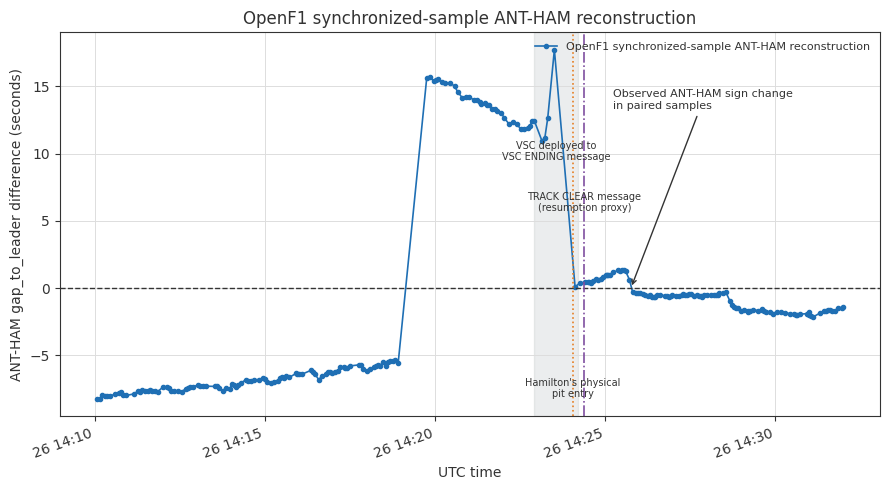

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    synchronized["ant_date"],
    synchronized["ANT_minus_HAM"],
    marker="o",
    markersize=3,
    linewidth=1.2,
    color="#1f6fb4",
    label="OpenF1 synchronized-sample ANT-HAM reconstruction",
)
ax.axhline(0, color="#333333", linewidth=1, linestyle="--")

ax.axvspan(fastf1_vsc_deployed_utc.tz_localize(None), fastf1_vsc_ending_utc.tz_localize(None),
           color="#7f8c8d", alpha=0.15)
ax.annotate(
    "VSC deployed to\nVSC ENDING message",
    xy=(fastf1_vsc_deployed_utc.tz_localize(None) + (fastf1_vsc_ending_utc - fastf1_vsc_deployed_utc) / 2,
        ax.get_ylim()[1] * 0.5 if ax.get_ylim()[1] > 0 else 5),
    ha="center", fontsize=7,
)

# Mark Hamilton's physical pit entry using the OpenF1 pit record directly
# (already an absolute UTC timestamp), rather than converting FastF1's
# session-relative field.
with open(evidence_dir / "openf1_pit_driver_44.json") as f:
    ham_pit_raw = json.load(f)
ham_pit_df = pd.DataFrame(ham_pit_raw)
ham_pit_df["date"] = pd.to_datetime(ham_pit_df["date"], format="ISO8601")
ham_vsc_stop = ham_pit_df.loc[ham_pit_df["lap_number"].eq(56)].iloc[0]
ham_pit_utc = ham_vsc_stop["date"].tz_localize(None)

ax.axvline(ham_pit_utc, color="#e67e22", linewidth=1.2, linestyle=":")
ax.annotate(
    "Hamilton's physical\npit entry",
    xy=(ham_pit_utc, ax.get_ylim()[0] * 0.85 if ax.get_ylim()[0] < 0 else -2),
    ha="center", fontsize=7,
)

ax.axvline(track_clear_utc.tz_localize(None), color="#7f4fa0", linewidth=1.2, linestyle="-.")
ax.annotate(
    "TRACK CLEAR message\n(resumption proxy)",
    xy=(track_clear_utc.tz_localize(None), ax.get_ylim()[1] * 0.3 if ax.get_ylim()[1] > 0 else 3),
    ha="center", fontsize=7,
)

ax.annotate(
    "Observed ANT-HAM sign change\nin paired samples",
    xy=(sign_change_midpoint.tz_localize(None), 0),
    xytext=(pd.Timestamp("2026-07-26 14:25:15"), ax.get_ylim()[1] * 0.7),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", lw=1, color="#333333"),
)

ax.set_xlabel("UTC time")
ax.set_ylabel("ANT-HAM gap_to_leader difference (seconds)")
ax.set_title("OpenF1 synchronized-sample ANT-HAM reconstruction")
ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.autofmt_xdate(rotation=20)
fig.tight_layout()
plt.show()

*Figure 2. OpenF1 synchronized-sample ANT-HAM reconstruction, built by
pairing each driver's nearest `gap_to_leader` observation within a
two-second tolerance (see the sensitivity table above for the one- and
four-second alternatives). This is not an official, continuously sampled
interval. The positive-to-negative sign change is bracketed between one
paired observation on each side of the transition, identical across the
one-, two-, and four-second tolerances tested, rather than timestamped
exactly; the bracket does not by itself identify or explain the
white-line/control-line decision described in the text. The shaded band
spans VSC deployment to the `VSC ENDING` message only, not the complete
neutralization, since `TRACK CLEAR`, used in this notebook as the
resumption proxy, followed roughly eleven seconds later and is marked
separately. Hamilton's physical pit entry is marked directly from the
preserved OpenF1 pit record.*

## Pit and stint context

A pit stop's cost is not one number. It is a stationary stop, a pit-lane
traversal at a speed limit, whatever pace the rest of the field is running
while that car is off-line, and afterward, however long the tyres take
to reach temperature. The table below compares what OpenF1 and FastF1
actually document for each driver's relevant stop, using `lane_duration`
rather than the deprecated `pit_duration` field.

In [11]:
with open(evidence_dir / "openf1_pit_driver_12.json") as f:
    ant_pit_raw = json.load(f)
with open(evidence_dir / "openf1_pit_driver_44.json") as f:
    ham_pit_raw_local = json.load(f)
with open(evidence_dir / "openf1_stints_driver_12.json") as f:
    ant_stints_raw = json.load(f)
with open(evidence_dir / "openf1_stints_driver_44.json") as f:
    ham_stints_raw = json.load(f)

ant_pit_df = pd.DataFrame(ant_pit_raw)
ant_pit_df["date"] = pd.to_datetime(ant_pit_df["date"], format="ISO8601")
ham_pit_df_local = pd.DataFrame(ham_pit_raw_local)
ham_pit_df_local["date"] = pd.to_datetime(ham_pit_df_local["date"], format="ISO8601")
ant_stints_df = pd.DataFrame(ant_stints_raw)
ham_stints_df = pd.DataFrame(ham_stints_raw)

ant_green_stop = ant_pit_df.loc[ant_pit_df["lap_number"].eq(53)].iloc[0]
ham_vsc_stop_row = ham_pit_df_local.loc[ham_pit_df_local["lap_number"].eq(56)].iloc[0]

assert "lane_duration" in ant_pit_df.columns and "lane_duration" in ham_pit_df_local.columns
assert "stop_duration" in ant_pit_df.columns and "stop_duration" in ham_pit_df_local.columns
assert pd.isna(ant_green_stop["stop_duration"]), (
    "Expected Antonelli's lap-53 stop_duration to be null in this evidence file"
)
assert pd.isna(ham_vsc_stop_row["stop_duration"]), (
    "Expected Hamilton's lap-56 stop_duration to be null in this evidence file"
)

assert set(ant_stints_df["session_key"]) == {11342}
assert set(ham_stints_df["session_key"]) == {11342}

ant_new_stint = ant_stints_df.loc[ant_stints_df["lap_start"].eq(54)].iloc[0]
ham_new_stint = ham_stints_df.loc[ham_stints_df["lap_start"].eq(57)].iloc[0]

pit_stint_comparison = pd.DataFrame([
    {
        "Driver": "Antonelli (ANT)",
        "Lap": 53,
        "TrackStatus": "Green flag",
        "PitLaneDurationSec": ant_green_stop["lane_duration"],
        "NewCompound": ant_new_stint["compound"],
        "TyreAgeAtStintStart": ant_new_stint["tyre_age_at_start"],
    },
    {
        "Driver": "Hamilton (HAM)",
        "Lap": 56,
        "TrackStatus": "VSC deployed",
        "PitLaneDurationSec": ham_vsc_stop_row["lane_duration"],
        "NewCompound": ham_new_stint["compound"],
        "TyreAgeAtStintStart": ham_new_stint["tyre_age_at_start"],
    },
])
print(pit_stint_comparison.to_string(index=False))

lane_duration_delta = ham_vsc_stop_row["lane_duration"] - ant_green_stop["lane_duration"]
print()
print(
    f"Hamilton's VSC-window pit-lane duration was {lane_duration_delta:+.1f} s "
    "relative to Antonelli's green-flag stop -- longer, not shorter."
)
print(
    "The OpenF1 `stop_duration` field (stationary service time) is null for "
    "both of these records, so this notebook cannot compare how long either "
    "car was stationary in its pit box -- only the total pit-lane transit "
    "duration (`lane_duration`) above."
)
assert lane_duration_delta > 0

         Driver  Lap  TrackStatus  PitLaneDurationSec NewCompound  TyreAgeAtStintStart
Antonelli (ANT)   53   Green flag                21.3        HARD                    0
 Hamilton (HAM)   56 VSC deployed                22.4        SOFT                    3

Hamilton's VSC-window pit-lane duration was +1.1 s relative to Antonelli's green-flag stop -- longer, not shorter.
The OpenF1 `stop_duration` field (stationary service time) is null for both of these records, so this notebook cannot compare how long either car was stationary in its pit box -- only the total pit-lane transit duration (`lane_duration`) above.


That last line is worth sitting with. Hamilton's own pit-lane duration
under the VSC was not shorter than Antonelli's green-flag stop a few laps
earlier; it was 1.1 seconds longer in total pit-lane transit
(`lane_duration`). That rules out one possible explanation for Hamilton's
VSC-window advantage: it cannot be attributed to a shorter overall
pit-lane traversal, since his was the longer of the two. It does,
however, let this notebook say anything about stationary service time on
its own, because OpenF1's `stop_duration` field, the portion of
`lane_duration` spent stationary in the pit box, is null for both of
these records. Whatever made Hamilton's stop cheap in race-time terms
operated through every other car on track running at reduced VSC pace
while he was in the pits, which the pit-lane duration figures above do not
capture at all, and this notebook does not estimate how many seconds that
was worth. This is exactly why this notebook treats "pit-lane duration"
and "time saved by stopping under the VSC" as two different things, and
does not use the shorter of the two race-time figures as if it were a
pit-stop-performance result.

### One bounded comparison, not a counterfactual

The two stops above are the only ones this notebook compares, and the
comparison window, Antonelli's own green-flag stop against Hamilton's own
VSC-window stop, was fixed before either `lane_duration` value was
inspected, because it is the one comparison this story is already about.
Track-status conditions are stated explicitly (green vs. VSC), the timing
grain is identical (`lane_duration` from the same OpenF1 endpoint for both),
and the result above is used only to describe what is documented about
these two specific stops. It says nothing about what either driver's stop
would have cost under the other's conditions, and it is not a substitute
for a genuine green-flag-versus-VSC counterfactual, which this notebook
does not attempt.

## Event timeline

The events below are kept separate rather than collapsed into one moment:
the physical stop (from OpenF1's own timestamped pit record), the VSC
procedure (from FastF1's race-control messages), the observed ANT-HAM
sign-change bracket (from the synchronized-sample reconstruction), and the
penalty and final classification (from the FIA).

In [12]:
ant_pit_utc = ant_green_stop["date"].tz_localize(None)
ham_pit_utc_value = ham_vsc_stop_row["date"].tz_localize(None)

speeding_noted = rcm.loc[
    rcm["Message"].str.contains("SPEEDING IN THE PIT LANE", case=False, na=False)
    & rcm["Message"].str.contains("NOTED", case=False, na=False)
].iloc[0]
penalty_confirmed = rcm.loc[
    rcm["Message"].str.contains("5 SECOND TIME PENALTY FOR CAR 44", case=False, na=False)
].iloc[0]

sign_change_last_positive_ant_time_naive = sign_change_last_positive_ant_time.tz_localize(None)
sign_change_first_negative_ant_time_naive = sign_change_first_negative_ant_time.tz_localize(None)

event_timeline = pd.DataFrame([
    {"UTCTime": ant_pit_utc, "Lap": 53, "Event": "Antonelli's physical pit entry (green flag)", "Source": "OpenF1 pit record"},
    {"UTCTime": fastf1_vsc_deployed_utc.tz_localize(None), "Lap": 56, "Event": "VSC deployed", "Source": "FastF1 race control"},
    {"UTCTime": ham_pit_utc_value, "Lap": 56, "Event": "Hamilton's physical pit entry (VSC window)", "Source": "OpenF1 pit record"},
    {"UTCTime": fastf1_vsc_ending_utc.tz_localize(None), "Lap": 57, "Event": "VSC ENDING message", "Source": "FastF1 race control"},
    {"UTCTime": track_clear_utc.tz_localize(None), "Lap": 57, "Event": "TRACK CLEAR message (resumption proxy)", "Source": "FastF1 race control"},
    {"UTCTime": sign_change_last_positive_ant_time_naive, "Lap": 58, "Event": f"Last positive ANT-HAM paired observation ({sign_change_last_positive_value:+.3f}s)", "Source": "OpenF1 synchronized-sample reconstruction"},
    {"UTCTime": sign_change_first_negative_ant_time_naive, "Lap": 58, "Event": f"First negative ANT-HAM paired observation ({sign_change_first_negative_value:+.3f}s)", "Source": "OpenF1 synchronized-sample reconstruction"},
    {"UTCTime": speeding_noted["Time"], "Lap": int(speeding_noted["LapNumeric"]), "Event": "Hamilton pit-lane-speeding incident noted", "Source": "FastF1 race control"},
    {"UTCTime": penalty_confirmed["Time"], "Lap": int(penalty_confirmed["LapNumeric"]), "Event": "Hamilton's 5-second penalty confirmed", "Source": "FastF1 race control"},
])
event_timeline = event_timeline.sort_values("UTCTime").reset_index(drop=True)
print(event_timeline.to_string(index=False))

gap_seconds_penalty_after_sign_change = (
    penalty_confirmed["Time"] - sign_change_first_negative_ant_time_naive
).total_seconds()
print()
print(
    f"The penalty was confirmed {gap_seconds_penalty_after_sign_change:.0f} seconds "
    "after the observed sign change -- a separate, later procedural step, "
    "not the same event."
)
assert gap_seconds_penalty_after_sign_change > 500

                UTCTime  Lap                                               Event                                    Source
2026-07-26 14:19:33.974   53         Antonelli's physical pit entry (green flag)                         OpenF1 pit record
2026-07-26 14:22:55.000   56                                        VSC deployed                       FastF1 race control
2026-07-26 14:24:03.700   56          Hamilton's physical pit entry (VSC window)                         OpenF1 pit record
2026-07-26 14:24:13.000   57                                  VSC ENDING message                       FastF1 race control
2026-07-26 14:24:24.000   57              TRACK CLEAR message (resumption proxy)                       FastF1 race control
2026-07-26 14:25:43.495   58  Last positive ANT-HAM paired observation (+0.631s) OpenF1 synchronized-sample reconstruction
2026-07-26 14:25:49.168   58 First negative ANT-HAM paired observation (-0.288s) OpenF1 synchronized-sample reconstruction
2026-07-26 14:30

## Why lap 58 was not an overtake

It would be easy to read the sign flip in Figure 1, Hamilton ahead by
1.4 seconds at his pit-out boundary, Antonelli ahead by 0.7 seconds one lap
later, as a pass. The timing data by itself cannot tell the difference:
both reconstructions show and bracket an ANT-HAM sign change, but a sign
change in a paired timing series is consistent with several different
mechanisms, an overtake, a voluntary position return, one driver slowing,
or something else entirely. The timing data alone does not determine which
one happened here.

What settles it is the official record. Formula 1's own race report says
Hamilton "initially emerged from that final stop ahead of Antonelli, only
to cede the position after replays showed he had reached the relevant VSC
white line at the end of the start/finish straight just behind the
Mercedes" (Formula 1, race report, accessed 2026-07-31). The FIA's summary
describes the same event in its own terms: Hamilton "initially appeared to
have retained the final podium place during the VSC sequence, but timing at
the relevant control line placed the Mercedes ahead" (FIA, race summary,
accessed 2026-07-31). Two independent official accounts describe a review
of where each car crossed a specific line relative to the VSC procedure,
not a car driven past another. The OpenF1 timing series used in this
notebook does not, by itself, establish that mechanism; it only shows that
something changed the order within a narrow, bracketed window, which is
consistent with the official accounts rather than a substitute for them.

Hamilton pushed back on the decision that put him there at all, saying
afterward, "I would never have stopped if it would have meant giving up
track position," and that his tyres "were totally fine" beforehand (quoted
in Crash.net and GPBlog, accessed 2026-07-31), a driver's frustration
with the strategy call, not a dispute over the control-line finding. This
notebook does not adjudicate the VSC control-line procedure itself beyond
citing the regulatory transition described in the methods appendix; that is
a narrower, better-supported claim than trying to derive the mechanism from
timing data alone.

## What the evidence supports

Put together, the FastF1 lap-boundary series, the OpenF1 synchronized-sample
reconstruction, and the two official accounts support a specific, bounded
sequence. Antonelli led by 6.002 seconds at lap 52, before his own stop.
That stop temporarily put Hamilton 14.190 seconds ahead at lap 54, simply
because Antonelli was the one who had just paid the pit-lane cost. Hamilton
was still 15.689 seconds ahead at his own pit-in boundary on lap 56; his
provisional lead had grown, not shrunk, while he continued circulating on
his older tyres. His VSC-window stop then reduced that provisional lead
sharply: to 1.388 seconds at his pit-out boundary on lap 57. One lap later,
Antonelli was 0.658 seconds ahead. The two cars' track order changed hands
at a specific line and moment identified independently by Formula 1 and the
FIA, not through a passing move, and Antonelli held the position from there
to the flag. Hamilton's own five-second penalty for pit-lane speeding,
confirmed on lap 66, came from an unrelated infringement during the same
stop and is a separate story from the position review itself.

## What it cannot prove

None of the above should be read as more than it is. This notebook does not
claim, and the evidence does not support, that the VSC cost Antonelli any
exact number of seconds; pit-lane duration, on-track VSC pace, and normal
race pace are three different quantities, and only two of the three are
directly measured here. It does not claim Hamilton would have passed or
beaten Antonelli without the white-line correction; the correction was a
timing review, and no version of this data models what either driver would
have done under different regulatory circumstances. It does not claim
Antonelli would certainly have lost the podium without the VSC arriving
when it did; Mercedes' own account frames the VSC as making an already
difficult defense harder, not as the sole reason Antonelli finished where
he did: "The Virtual Safety Car was not ideal as it reduced that advantage
and brought Lewis onto our gearbox, but Kimi managed the situation well and
defended strongly to secure P3" (Mercedes-AMG PETRONAS F1 Team, race
report, accessed 2026-07-31). It does not claim the lap-58 change was an
overtake, and it does not treat a shorter pit-lane duration as a measurement
of time saved by stopping under the VSC, for the reasons already laid out
above. Where the data cannot support a stronger reading, this notebook has
tried to say so plainly rather than resolve the ambiguity for the sake of a
tidier story.

## Sporting consequence

The position return itself did not decide Hamilton's final result. His
five-second penalty for pit-lane speeding, for a recorded 80.1 km/h
against an 80 km/h limit, an infringement of Article B1.6.3a.iii of the FIA
Formula 1 Sporting Regulations, confirmed in FIA Document 57, is what
actually dropped him from fourth on the road to fifth in the final
classification, seven-tenths of a second behind Charles Leclerc (FIA,
Document 62, Final Race Classification, accessed 2026-07-31). Those are two
separate procedural events, chronologically and substantively: the
control-line review settled the order between Hamilton and Antonelli inside
the VSC sequence itself, on lap 58; the penalty, confirmed on lap 66, is
what pushed Hamilton down the order relative to his own teammate. Antonelli
finished third, 18.728 seconds behind the race winner, having defended that
position from the point of the correction to the chequered flag. This is a
fact worth stating plainly, since none of the analysis above should be read
as diminishing that he still had a race left to finish.

## Conclusion

A tyre-offset strategy is a bet against time itself: that whatever
advantage a driver banks early will still be worth more than the position
spent building it once the tyres are actually needed. Antonelli's bet
mostly paid off, and the pit cycle around the VSC was the point where it
came closest to not paying off at all. Hamilton's own provisional lead,
built simply by being the one car of the two still circulating, reached
fifteen and a half seconds before his own stop cut it to under a second and
a half in a single lap, at which point the two cars' track order changed
hands under official review rather than on pace. Mercedes' own account
frames the underlying strategic picture plainly: the VSC "reduced" the
tyre-life advantage the team had built for Antonelli. That is a different
claim from the lap-boundary track gap traced above, and this notebook has
tried to keep the two separate throughout rather than treat one as a proxy
for the other. What the numbers show is narrower than a dramatic pass or a
strategy vindicated: a real, measurable compression of a real advantage,
resolved by a rule most viewers never see applied, on a lap that looked far
more dramatic on television than it was under the timing sheets.

## Methods and reproducibility appendix

**Independence.** This notebook loads its own FastF1 session (`session =
fastf1.get_session(2026, "Hungary", "R")`) and reads only preserved evidence
files; it does not import, execute, or hold any in-memory dependency on
Notebook 1 or Notebook 2. It runs correctly whether launched from the
repository root or from within `notebooks/`, via the repository-relative
path resolution used in the input-validation and evidence-loading cells
above.

**Dependencies.** The analytical packages used are `fastf1`, `pandas`,
`numpy`, and `matplotlib`, all already listed in this project's
`requirements.txt`. The environment-reporting cell additionally imports
`IPython` and `ipykernel` to record the running kernel's identity. No
package was installed for this notebook.

**Evidence.** `evidence/openf1_hungary_2026_race_control.json` is used to
cross-check the VSC timestamps. The shared position-response file supports
Notebook 1's position-identity reconstruction and is not used in this
notebook's calculations. `evidence/antonelli_hamilton_vsc/` is new: six raw
OpenF1 responses (`intervals` for drivers 12 and 44 over the bounded
2026-07-26T14:10:00-14:32:00 UTC window; full-session `pit` and `stints`
for both drivers), retrieved directly from the OpenF1 API endpoint,
validated for HTTP status, JSON structure, session key, driver number,
expected fields, timestamp parseability, duplicate records, and window
compliance before being copied into the repository verbatim. Its own
`README.md` in that directory records the exact endpoint, parameters,
resolved URL, retrieval timestamp, row and byte counts, and SHA-256
checksum for each file.

**What was rejected.** No comparison other than the Antonelli-green-flag
vs. Hamilton-VSC pit-lane-duration check in the Pit and stint context
section was promoted into this article. No stay-out, no-VSC, or
alternative-strategy counterfactual was constructed for either driver at
any point.

**Limitations.** The FastF1 lap-boundary metric compares total elapsed time
to complete the same lap number, not live position at one instant. The
OpenF1 synchronized-sample reconstruction's primary two-second-tolerance
pairing covers 73.2% of Antonelli's samples, with a 698 ms median skew and
a 1.979 s maximum skew; the positive-to-negative sign change it identifies
is bracketed between one paired observation on each side of the
transition, and that bracket is identical across the one-, two-, and
four-second tolerances tested. That bracket is an observed sample-level
sign change, not an exact event timestamp, and it does not by itself
identify the mechanism behind the position change (see "Why lap 58 was not
an overtake"). `TRACK CLEAR` is used as this notebook's timestamped
resumption proxy because it follows `VSC ENDING` by 11 seconds, consistent
with the 10-15 second panel-change window described in FIA 2026 Sporting
Regulations, Section B, Article B5.12.4; it is not independently
verified light-panel telemetry. The OpenF1 `stop_duration` field
(stationary service time) is null for both Antonelli's lap-53 and
Hamilton's lap-56 pit records, so this notebook makes no stationary-stop
comparison and estimates no no-VSC counterfactual for either stop. No
claim in this notebook rests on a corner-level or sub-second telemetry
mechanism.

## Source audit

Every source below was opened and read directly as part of preparing this
notebook; none is cited from a secondhand summary. The
`ContainsExactChronology` and `ExplainsWhiteLine` columns are human
editorial judgments recorded after reading each source in full, not
values scraped, parsed, or automatically verified from the page text. This
audit is bounded to the specific sources listed below; it does not, and
cannot, establish that no other publication anywhere contains this
notebook's chronology.

In [13]:
source_audit = pd.DataFrame([
    {
        "Publisher": "Formula 1 (official)",
        "Title": "Norris beats Verstappen and Antonelli to victory in dramatic Hungarian GP",
        "PublicationDate": "2026-07-26",
        "URL": "https://www.formula1.com/en/latest/article/norris-beats-verstappen-and-antonelli-to-victory-in-dramatic-hungarian-gp.5JQmohRAKABD2asRsMWogj",
        "RelevantClaim": "Hamilton emerged ahead of Antonelli but ceded the place after replays showed Antonelli reached the VSC white line first.",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": True,
        "AccessDate": "2026-07-31",
    },
    {
        "Publisher": "FIA (official)",
        "Title": "F1 - Norris wins Hungary, Piastri retires and Verstappen claims second ahead of Antonelli",
        "PublicationDate": "2026-07-26",
        "URL": "https://www.fia.com/news/f1-norris-wins-hungary-piastri-retires-and-verstappen-claims-second-ahead-antonelli",
        "RelevantClaim": "Hamilton appeared to retain the podium place, but timing at the relevant control line placed Antonelli ahead.",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": True,
        "AccessDate": "2026-07-31",
    },
    {
        "Publisher": "Mercedes-AMG PETRONAS F1 Team (official)",
        "Title": "Race report: impressive fightbacks and damage limitation in Budapest",
        "PublicationDate": "2026-07-26/27 (exact date not stated on page)",
        "URL": "https://www.mercedesamgf1.com/reports/race-report-impressive-fightbacks-and-damage-limitation-in-budapest",
        "RelevantClaim": "The VSC reduced Antonelli's tyre-life advantage and brought Hamilton close behind; Antonelli still defended P3.",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": False,
        "AccessDate": "2026-07-31",
    },
    {
        "Publisher": "Pit Debrief (independent analytical)",
        "Title": "Vasseur reflects on Ferrari's underperformance and defends pitting Hamilton under the VSC at 2026 F1 Hungarian GP",
        "PublicationDate": "2026-07-28 (approximate)",
        "URL": "https://www.pitdebrief.com/post/vasseur-reflects-on-ferraris-underperformance-and-defends-pitting-hamilton-under-the-vsc-at-2026-f1-hungarian-gp/",
        "RelevantClaim": "Vasseur explains Ferrari's tyre-strategy reasoning for pitting Hamilton under the VSC.",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": False,
        "AccessDate": "2026-07-31",
    },
    {
        "Publisher": "Crash.net (independent journalism)",
        "Title": "'I would never have stopped' - Lewis Hamilton critical of Ferrari's Hungary strategy",
        "PublicationDate": "2026-07-26",
        "URL": "https://www.crash.net/f1/news/1101944/1/i-would-never-have-stopped-lewis-hamilton-critical-ferraris-hungary-strategy",
        "RelevantClaim": "Hamilton says he ceded the place to Antonelli to avoid a penalty for overtaking under VSC, and disagreed with the stop.",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": False,
        "AccessDate": "2026-07-31",
    },
    {
        "Publisher": "GPBlog (independent journalism)",
        "Title": "Hamilton blames unnecessary Ferrari VSC pit stop for late Hungarian GP penalty",
        "PublicationDate": "2026-07-26",
        "URL": "https://www.gpblog.com/en/news/hamilton-blames-unnecessary-ferrari-vsc-pit-stop-for-late-hungarian-gp-penalty",
        "RelevantClaim": "Hamilton: 'In hindsight, my tyres were totally fine. I was probably going to lose out to Max but I think I could have kept third at least.'",
        "ContainsExactChronology": False,
        "ExplainsWhiteLine": False,
        "AccessDate": "2026-07-31",
    },
])

pd.set_option("display.max_colwidth", 60)
print(source_audit.to_string(index=False))

required_columns = {
    "Publisher", "Title", "PublicationDate", "URL", "RelevantClaim",
    "ContainsExactChronology", "ExplainsWhiteLine", "AccessDate",
}
assert required_columns.issubset(source_audit.columns), "Missing required audit columns"
assert len(source_audit) > 0, "Source audit table is empty"
assert source_audit["URL"].notna().all(), "Source audit has a missing URL"
assert source_audit["URL"].str.startswith("https://").all(), "Source audit has a non-https URL"
assert source_audit["AccessDate"].notna().all(), "Source audit has a missing access date"
print()
print(
    "The exact quantitative chronology in this notebook (the five "
    "lap-boundary values and the synchronized-sample reconstruction) was "
    "not identified in the sources reviewed as of 2026-07-31. The "
    "white-line/control-line mechanism itself is already officially "
    "documented by Formula 1 and the FIA, and this notebook credits both "
    "directly rather than re-deriving or re-discovering that explanation."
)

                               Publisher                                                                                                             Title                               PublicationDate                                                                                                                                               URL                                                                                                                               RelevantClaim  ContainsExactChronology  ExplainsWhiteLine AccessDate
                    Formula 1 (official)                                         Norris beats Verstappen and Antonelli to victory in dramatic Hungarian GP                                    2026-07-26       https://www.formula1.com/en/latest/article/norris-beats-verstappen-and-antonelli-to-victory-in-dramatic-hungarian-gp.5JQmohRAKABD2asRsMWogj                    Hamilton emerged ahead of Antonelli but ceded the place after replays showed Antonelli reach

### References

- FIA, Document 57, Infringement, Car 44, Pit lane speeding:
  <https://www.fia.com/system/files/decision-document/2026_hungarian_grand_prix_-_infringement_-_car_44_-_pit_lane_speeding.pdf>
- FIA, Document 62, Final Race Classification:
  <https://www.fia.com/system/files/decision-document/2026_hungarian_grand_prix_-_final_race_classification.pdf>
- FIA, 2026 Formula 1 Regulations, Section B [Sporting], Issue 07, Article
  B5.12.4 (Withdrawal of VSC):
  <https://www.fia.com/system/files/documents/fia_2026_f1_regulations_-_section_b_sporting_-_iss_07_-_2026-06-25.pdf>
- FIA, race summary:
  <https://www.fia.com/news/f1-norris-wins-hungary-piastri-retires-and-verstappen-claims-second-ahead-antonelli>
- Formula 1, official race report:
  <https://www.formula1.com/en/latest/article/norris-beats-verstappen-and-antonelli-to-victory-in-dramatic-hungarian-gp.5JQmohRAKABD2asRsMWogj>
- Mercedes-AMG PETRONAS F1 Team, race report:
  <https://www.mercedesamgf1.com/reports/race-report-impressive-fightbacks-and-damage-limitation-in-budapest>
- FastF1 documentation, time representation:
  <https://docs.fastf1.dev/time_explanation.html>
- OpenF1 API documentation:
  <https://openf1.org/docs/>
- Pit Debrief:
  <https://www.pitdebrief.com/post/vasseur-reflects-on-ferraris-underperformance-and-defends-pitting-hamilton-under-the-vsc-at-2026-f1-hungarian-gp/>
- Crash.net:
  <https://www.crash.net/f1/news/1101944/1/i-would-never-have-stopped-lewis-hamilton-critical-ferraris-hungary-strategy>
- GPBlog:
  <https://www.gpblog.com/en/news/hamilton-blames-unnecessary-ferrari-vsc-pit-stop-for-late-hungarian-gp-penalty>

All access dates 2026-07-31.